# Models like BERT or LLaMA are very large models. How can we address this issue?

The escalating scale of modern Transformer architectures—such as BERT  and LLaMA —presents profound computational bottlenecks. As parameter counts scale into tens or hundreds of billions, these models demand prohibitive memory footprints and high-latency inference. This research overview details established architectural and mathematical optimization techniques utilized to mitigate these bottlenecks, enabling deployment on resource-constrained hardware.

Quantization: Converts parameters from 16-bit floating-point (FP16) down to 8-bit or 4-bit (INT8/INT4). This shrinks the model's RAM usage dramatically with minimal loss in accuracy.

Quantization works by converting 16-bit floats to lower-precision formats like 8-bit or 4-bit integers, significantly reducing model size. For instance, a 7B-parameter model that typically requires 14 GB of VRAM in FP16 can shrink to just 4 GB in INT4. This reduction eases memory bandwidth demands, a common bottleneck in streaming scenarios. NVIDIA H100 GPUs, capable of running FP8 operations as fast as INT8, can boost throughput by up to 2.2× for models like Llama2-70B compared to FP16.

In 2025, Databricks successfully quantized the Llama2-70B-Chat model to FP8 using NVIDIA TensorRT-LLM. The results? A model that was 50% smaller, delivered 2.2× higher throughput, and improved time-to-first-token by 30%. A Databricks engineer highlighted the core advantage:

“Quantization’s greatest benefit is that it unlocks higher concurrency, because it allows us to double the maximum batch size that can fit on the same hardware while maintaining the same latency budget.”

Quantizing the Key-Value (KV) cache to INT8 or FP8 further reduces persistent memory usage, enabling 2–3× larger batch sizes and increased concurrency for streaming workflows. Interestingly, FP8 often outperforms INT8 because its non-uniform distribution better captures the bell curve and outliers typical of model weights. These memory savings directly reduce inference latency in streaming applications.

Here’s a quick comparison of common quantization methods:

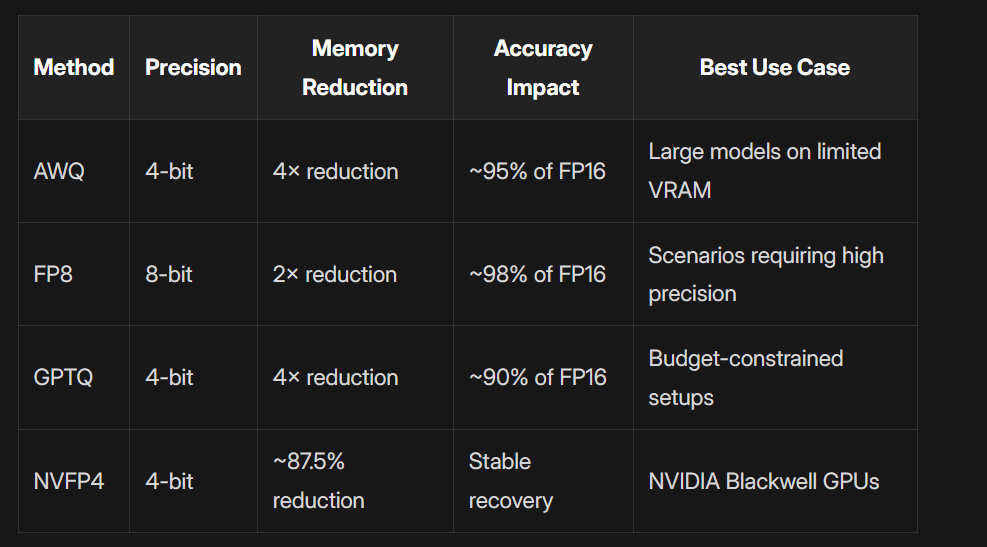

# Tensor Parallelism Across Multiple GPUs

Tensor parallelism complements quantization by distributing a model’s workload across multiple GPUs, enabling efficient handling of larger models.

This approach splits a model’s weight matrices across GPUs, allowing each device to manage part of the computation. By pooling the VRAM of all GPUs, tensor parallelism makes it possible to run massive models - like Llama-70B - that would otherwise exceed the capacity of a single GPU. This method can cut per-GPU memory requirements by up to 80%.

However, synchronization between GPUs is required after each layer, achieved through AllReduce operations using NVIDIA’s NCCL backend. This makes interconnect speed critical. For example, a TP=4 setup on NVLink achieved 220 tokens per second - nearly double the 120 tokens per second on a PCIe Gen3 connection - with interconnect overheads ranging from 10% to 30%. Note that duplicating the KV cache across TP ranks adds about 20% extra memory usage. Techniques like PagedAttention can lower KV memory fragmentation from around 70% to under 4%.

In 2025, Perplexity AI upgraded to NVIDIA H100 GPUs, slashing latency by 54% and increasing throughput by 184%. Adding FP8 optimization further reduced latency by 49% and boosted throughput by 202%.

Rajvir Singh from NVIDIA emphasized:

“The trade-off between throughput and latency is driven by the number of concurrent requests and the latency budget, both determined by the application’s use case.”

When setting up tensor parallelism, ensure that the --tensor-parallel-size parameter matches your GPU count and divides evenly into the model’s number of attention heads (e.g., TP=4 for a model with 32 heads). To avoid errors, verify GPU topology and high-speed interconnect paths using tools like nvidia-smi topo -m. If out-of-memory issues arise, consider reducing --gpu-memory-utilization (e.g., to 0.85) or applying additional quantization.

# When does quantization hurt quality too much for streaming apps?

Quantization plays a critical role in determining the quality of streaming apps, especially when reducing precision causes accuracy to drop beyond acceptable limits. This issue is particularly pronounced with extremely low-bit formats like 4-bit or less. While these formats can shrink model sizes and enhance processing speed, the downside is often a significant loss in output quality. For real-time applications, this trade-off can render such formats impractical.

#Why Are Large Models a Problem

he main challenges of large models include:

High memory consumption.

Large storage requirements.

Slow inference time.

Increased power consumption
.
Difficulty deploying on edge devices such as laptops, smartphones, and embedded systems.

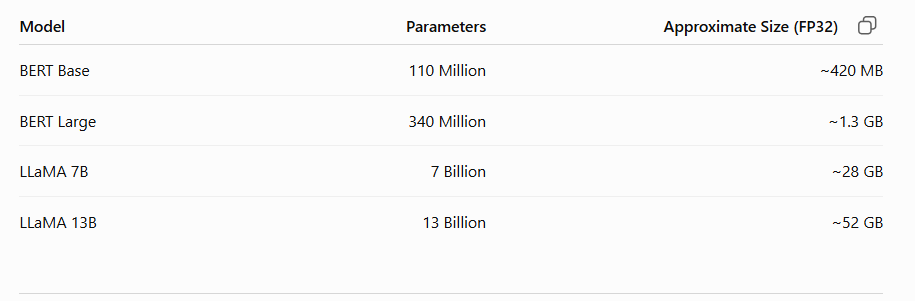

#Memory Comparison

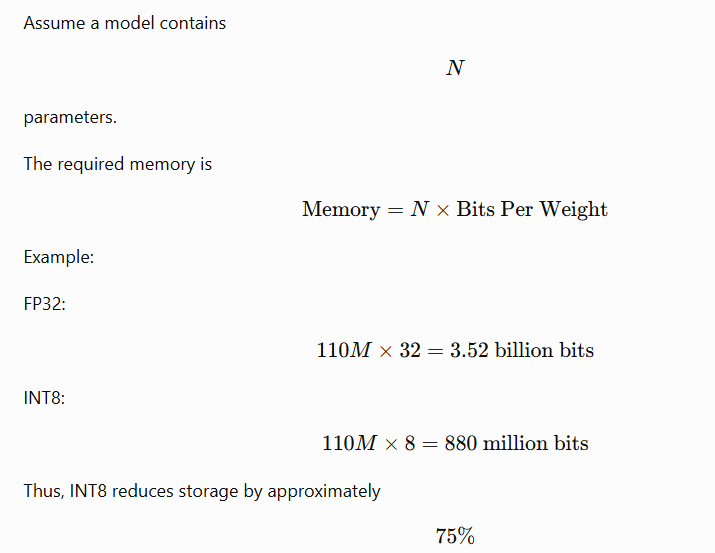

#Types of Quantization

1. Dynamic Quantization

Quantizes weights after training.
Easy to apply.
No retraining required.
Commonly used for BERT models.

Advantages:

Fast

Simple

Good accuracy

2. Static Quantization

Both weights and activations are quantized.

Requires calibration using representative data.

Produces better speed improvements than dynamic quantization.

3. Quantization-Aware Training (QAT)

The model is trained while simulating quantization.

Advantages:

Highest accuracy after quantization.

Disadvantages:

Requires retraining.
More computationally expensive.

#Dynamic Quantization with PyTorch

In [13]:
import torch
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased"
)

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

torch.save(
    quantized_model.state_dict(),
    "bert_quantized.pth"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_6129/33

In [17]:
from huggingface_hub import notebook_login

notebook_login()

#Loading an 8-bit LLaMA Model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    quantization_config=bnb_config,
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-2-7b-hf"
)

#4-bit Quantization

In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

#Advantages of Quantization
Reduces model size.

Faster inference.

Lower memory consumption.

Lower power usage.

Enables deployment on resource-constrained devices.

#Resources



*   ChatGPT
*   https://latitude.so/blog/real-time-llms-optimizing-latency-streaming


